In [ ]:
!pip install linearmodels openpyxl seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 5.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import ttest_ind, ttest_1samp

import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

try:
    from linearmodels.panel import PanelOLS
    HAS_LINEARMODELS = True
    print("✅ linearmodels tersedia")
except ImportError:
    HAS_LINEARMODELS = False
    print("⚠️  linearmodels tidak tersedia — pakai statsmodels cluster SE")

print("✅ Semua library berhasil di-import")

✅ linearmodels tersedia
✅ Semua library berhasil di-import


In [ ]:
from google.colab import files

print("📁 upload file xlsx ...")
uploaded = files.upload()

# Ambil nama file yang diupload
import io
FILENAME = list(uploaded.keys())[0]
print(f"✅ File berhasil diupload: {FILENAME}")

📁 upload file xlsx ...


Saving Tes Dataset (3).xlsx to Tes Dataset (3).xlsx
✅ File berhasil diupload: Tes Dataset (3).xlsx


In [ ]:
print("\n" + "="*60)
print("LOADING DAN PREPROCESSING DATA")
print("="*60)

# ── 4a. Load kedua sheet ────────────────────────────────────────────────────
df_liga = pd.read_excel(FILENAME, sheet_name="Liga Dataset")
df_cup  = pd.read_excel(FILENAME, sheet_name="Cup Dataset")

print(f"Liga loaded: {df_liga.shape[0]:,} baris × {df_liga.shape[1]} kolom")
print(f"Cup  loaded: {df_cup.shape[0]:,} baris × {df_cup.shape[1]} kolom")

# ── 4b. Bersihkan nama kolom  ──────────────────────────────────────────────
def clean_columns(df):
    df = df.copy()
    df.columns = (df.columns
                  .str.strip()
                  .str.replace('/', '_', regex=False)
                  .str.replace(' ', '_', regex=False)
                  .str.replace('-', '_', regex=False))
    return df

df_liga = clean_columns(df_liga)
df_cup  = clean_columns(df_cup)

print("\nKolom Liga:", list(df_liga.columns))
print("\nKolom Cup: ", list(df_cup.columns))

# ── 4c. Konversi tipe data ──────────────────────────────────────────────────
date_cols = ['Event_Date', 'Date_K']
for df in [df_liga, df_cup]:
    for c in date_cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors='coerce')

# ── 4d. Derived variables — LIGA ────────────────────────────────────────────
# CAR sub-windows
df_liga['CARpre']  = df_liga['AR_m2'] + df_liga['AR_m1'] + df_liga['AR_0']
df_liga['CARpost'] = df_liga['AR_p1'] + df_liga['AR_p2']

# Top League dummy
TOP_LEAGUES = ['Premier League', 'Serie A', 'Bundesliga']
df_liga['Top_League'] = df_liga['League'].isin(TOP_LEAGUES).astype(int)

# Big Match European Spots binary
df_liga['BM_Eur_Any'] = (df_liga['BM_European_Spots'] >= 1).astype(int)

# Away dummy
df_liga['Away'] = df_liga['Venue_Num'].fillna(0).astype(int)

# Market-adjusted AR (robustness check)
df_liga['CAR_madj'] = (
    (df_liga['R_m2'] - df_liga['RM_m2']) +
    (df_liga['R_m1'] - df_liga['RM_m1']) +
    (df_liga['R_0']  - df_liga['RM_0'])  +
    (df_liga['R_p1'] - df_liga['RM_p1']) +
    (df_liga['R_p2'] - df_liga['RM_p2'])
)

# ── 4e. Derived variables — CUP ─────────────────────────────────────────────
df_cup['CARpre']  = df_cup['AR_m2'] + df_cup['AR_m1'] + df_cup['AR_0']
df_cup['CARpost'] = df_cup['AR_p1'] + df_cup['AR_p2']

# Away dummy dari kolom Venue
if 'Venue' in df_cup.columns:
    df_cup['Away'] = df_cup['Venue'].map({'H': 0, 'A': 1, 'N': 0}).fillna(0).astype(int)

# Rename BM_Semi/Final
if 'BM_Semi_Final' not in df_cup.columns:
    for alt in ['BM_Semi_Final', 'BM_Semi__Final']:
        if alt in df_cup.columns:
            df_cup = df_cup.rename(columns={alt: 'BM_Semi_Final'})

# Knockout & Elimination (H5)
df_cup['Is_Knockout'] = (df_cup['Stage_Num'] >= 4).astype(int)
df_cup['Eliminated']  = ((df_cup['Is_Knockout'] == 1) &
                          (df_cup['Loss'] == 1)).astype(int)
df_cup['Advanced']    = ((df_cup['Is_Knockout'] == 1) &
                          (df_cup['Win'] == 1)).astype(int)

# ── 4f. Fixed effects sebagai category ─────────────────────────────────────
for df in [df_liga, df_cup]:
    df['Club']   = df['Club'].astype('category')
    df['Season'] = df['Season'].astype('category')

# ── 4g. Ringkasan statistik awal ────────────────────────────────────────────
print("\n" + "-"*60)
print("STATISTIK DASAR")
print("-"*60)
print(f"\nLiga: {df_liga['Club'].nunique()} klub | {df_liga['Season'].nunique()} musim")
print(f"  Win: {df_liga['Win'].sum()} ({df_liga['Win'].mean()*100:.1f}%) | "
      f"Draw: {(df_liga['Results']=='D').sum()} | "
      f"Loss: {df_liga['Loss'].sum()} ({df_liga['Loss'].mean()*100:.1f}%)")
print(f"  CAR mean: {df_liga['CAR'].mean():.5f} | std: {df_liga['CAR'].std():.5f}")

print(f"\nCup: {df_cup['Club'].nunique()} klub | {df_cup['Season'].nunique()} musim")
print(f"  Win: {df_cup['Win'].sum()} | Loss: {df_cup['Loss'].sum()}")
print(f"  CAR mean: {df_cup['CAR'].mean():.5f} | std: {df_cup['CAR'].std():.5f}")
print(f"  Elimination events: {df_cup['Eliminated'].sum()}")

print("\n✅ Preprocessing selesai")


LOADING DAN PREPROCESSING DATA
Liga loaded: 5,093 baris × 66 kolom
Cup  loaded: 2,258 baris × 63 kolom

Kolom Liga: ['Club', 'League', 'League_Size', 'Index', 'Season', 'Event_Date', 'Matchday', 'Venue', 'Venue_Num', 'Ranking', 'Rank_Strength', 'Results', 'Results_Num', 'Win', 'Loss', 'WinPct_3', 'WinPct_5', 'WinPct_10', 'Rank_imp_3', 'Rank_imp_5', 'Rank_imp_10', 'Opponents', 'Opponents_Rank', 'Opponents_Rank_Strength', 'Relative_Delta_Strength', 'BM_Close_Odds', 'BM_European_Spots', 'BM_Rivals', 'BM_Title_Race', 'BM_Relegation_Battle', 'BM_Any', 'K', 'Date_K', 'Price_K', 'R_m2', 'R_m1', 'R_0', 'R_p1', 'R_p2', 'RM_m2', 'RM_m1', 'RM_0', 'RM_p1', 'RM_p2', 'AR_m2', 'AR_m1', 'AR_0', 'AR_p1', 'AR_p2', 'CAR', 'Odds_Club', 'Implied_Prob', 'Favourite', 'Surprise', 'Beta', 'Alpha', 'ER_m2', 'ER_m1', 'ER_0', 'ER_p1', 'ER_p2', 'Rf_m2', 'Rf_m1', 'Rf_0', 'Rf_p1', 'Rf_p2']

Kolom Cup:  ['Club', 'League', 'League_Rank_Tier', 'League_Strength', 'Index', 'Season', 'Event_Date', 'Cup', 'Cup_Size', 'Reg

In [ ]:
def run_ols(formula, data, cluster_var='Club', print_result=True, label=''):
    """
    Jalankan Pooled OLS dengan clustered standard errors.

    Parameter:
        formula     : string formula statsmodels (e.g. "CAR ~ Win + Loss + ...")
        data        : DataFrame
        cluster_var : kolom untuk cluster SE (default: 'Club')
        print_result: tampilkan ringkasan koefisien
        label       : judul model untuk display

    Returns:
        RegressionResults object dari statsmodels
    """
    # Drop NaN hanya pada variabel yang ada di formula
    import re
    raw_vars = re.findall(r'[A-Za-z_][A-Za-z0-9_]*', formula.split('~')[1])
    check_vars = [v for v in raw_vars if v in data.columns and not v.startswith('C')]
    data_clean = data.dropna(subset=check_vars)

    model = smf.ols(formula, data=data_clean).fit(
        cov_type='cluster',
        cov_kwds={'groups': data_clean[cluster_var]}
    )

    if print_result:
        print(f"\n{'='*65}")
        print(f"MODEL: {label}")
        print(f"N = {int(model.nobs):,} | R² = {model.rsquared:.4f} | "
              f"Adj-R² = {model.rsquared_adj:.4f}")
        print(f"F-statistic = {model.fvalue:.3f} | Prob(F-statistic) = {model.f_pvalue:.4g}")
        print(f"{'─'*65}")
        print(f"{'Variabel':<35} {'Koef':>10} {'SE':>10} {'t':>8} {'p':>8}")
        print(f"{'─'*65}")

        # Hanya tampilkan variabel utama
        for var in model.params.index:
            if var.startswith('C(') or var == 'Intercept':
                continue
            b    = model.params[var]
            se   = model.bse[var]
            t    = model.tvalues[var]
            p    = model.pvalues[var]
            star = ('***' if p < 0.01 else '**' if p < 0.05 else
                    '*'   if p < 0.10 else '')
            print(f"  {var:<33} {b:>10.5f} {se:>10.5f} {t:>8.3f} {p:>7.3f} {star}")
        print(f"{'─'*65}")

    return model


def wald_test(model, constraint="Win + Loss = 0", label=""):
    """
    Wald test untuk kombinasi linear koefisien.
    Default: test asimetri loss aversion (β_Win + β_Loss = 0)
    """
    try:
        result = model.f_test(constraint)
        f      = float(result.fvalue)
        p      = float(result.pvalue)

        b_win  = model.params.get('Win', np.nan)
        b_loss = model.params.get('Loss', np.nan)
        ratio  = abs(b_loss/b_win) if b_win != 0 else np.nan

        print(f"\n[Wald Test — {label}]")
        print(f"  H₀: {constraint}")
        print(f"  β_Win  = {b_win:>8.5f}")
        print(f"  β_Loss = {b_loss:>8.5f}")
        if not np.isnan(ratio):
            print(f"  |β_Loss|/|β_Win| = {ratio:.3f}x", end="")
            if ratio > 1:
                print(" → |β_Loss| lebih besar (mendukung loss aversion)")
            else:
                print(" → |β_Win| lebih besar")
        print(f"  F = {f:.4f} | p = {p:.4f}", end="")
        if p < 0.01:
            print("  *** Tolak H₀ — asimetri SIGNIFIKAN (1%)")
        elif p < 0.05:
            print("  ** Tolak H₀ — asimetri SIGNIFIKAN (5%)")
        elif p < 0.10:
            print("  * Tolak H₀ — asimetri SIGNIFIKAN (10%)")
        else:
            print("  — Gagal tolak H₀ (tidak ada asimetri signifikan)")
        return {'f': f, 'p': p, 'b_win': b_win, 'b_loss': b_loss}
    except Exception as e:
        print(f"  ⚠️  Wald test error: {e}")
        return None


def ttest_vs_zero(series, label=""):
    """One-sample t-test: apakah mean CAR berbeda dari 0?"""
    clean = series.dropna()
    t, p = ttest_1samp(clean, 0)
    print(f"\n[t-test vs 0 — {label}]")
    print(f"  N = {len(clean)} | Mean = {clean.mean():.5f} | "
          f"t = {t:.4f} | p = {p:.4f}",
          end="")
    star = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else ''
    print(f" {star}")
    return {'n': len(clean), 'mean': clean.mean(), 't': t, 'p': p}


print("✅ Fungsi helper siap digunakan")

✅ Fungsi helper siap digunakan


In [ ]:
print("\n" + "="*65)
print("STATISTIK DESKRIPTIF")
print("="*65)

def descriptive_stats(df, label, result_col='CAR'):
    """Statistik deskriptif per kategori hasil."""
    print(f"\n{label} — CAR per Hasil Pertandingan:")
    print(f"{'Hasil':<8} {'N':>6} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10} {'t vs 0':>8} {'p':>8}")
    print("─"*70)

    for r, name in [('W','Win'), ('D','Draw'), ('L','Loss')]:
        sub = df[df['Results'] == r][result_col].dropna()
        if len(sub) == 0:
            continue
        t, p = ttest_1samp(sub, 0)
        star = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else ''
        print(f"  {name:<6} {len(sub):>6} {sub.mean():>10.5f} {sub.std():>10.5f} "
              f"{sub.min():>10.5f} {sub.max():>10.5f} {t:>8.3f} {p:>7.4f} {star}")

descriptive_stats(df_liga, "LIGA")
descriptive_stats(df_cup,  "CUP")

# AR per hari
print(f"\n{'Liga — Mean AR per hari (event window):'}")
for col, lbl in [('AR_m2','AR K-2'), ('AR_m1','AR K-1'), ('AR_0','AR K'),
                  ('AR_p1','AR K+1'), ('AR_p2','AR K+2'), ('CAR','CAR')]:
    t, p = ttest_1samp(df_liga[col].dropna(), 0)
    star = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else ''
    print(f"  {lbl:<8} mean={df_liga[col].mean():>9.5f}  t={t:>7.3f}  p={p:.4f} {star}")


STATISTIK DESKRIPTIF

LIGA — CAR per Hasil Pertandingan:
Hasil         N       Mean        Std        Min        Max   t vs 0        p
──────────────────────────────────────────────────────────────────────
  Win      3185    0.00811    0.07086   -0.67722    0.67623    6.459  0.0000 ***
  Draw     1008   -0.01182    0.06656   -0.54808    0.46284   -5.637  0.0000 ***
  Loss      900   -0.01898    0.06954   -0.67781    0.28414   -8.190  0.0000 ***

CUP — CAR per Hasil Pertandingan:
Hasil         N       Mean        Std        Min        Max   t vs 0        p
──────────────────────────────────────────────────────────────────────
  Win      1236    0.00888    0.06759   -0.50689    0.52182    4.621  0.0000 ***
  Draw      394    0.00255    0.05804   -0.22184    0.46542    0.873  0.3830 
  Loss      628   -0.00852    0.06715   -0.23537    0.74804   -3.178  0.0016 ***

Liga — Mean AR per hari (event window):
  AR K-2   mean= -0.00039  t= -0.793  p=0.4281 
  AR K-1   mean=  0.00067  t=  1.430 

In [ ]:
print("\n" + "="*65)
print("H1: PENGARUH HASIL PERTANDINGAN")
print("="*65)

# ── H1 Liga — Main ──────────────────────────────────────────────────────────
# CAR = β₀ + β₁Win + β₂Loss + β₃ΔS + β₄Away + αᵢ + γₛ + εᵢₜ
h1_liga = run_ols(
    "CAR ~ Win + Loss + Relative_Delta_Strength + Away + C(Club) + C(Season)",
    df_liga,
    label="H1 Liga — Main Effect (Win/Loss vs Draw)"
)

# ── H1 Liga — CARpre & CARpost ──────────────────────────────────────────────
h1_liga_pre = run_ols(
    "CARpre ~ Win + Loss + Relative_Delta_Strength + Away + C(Club) + C(Season)",
    df_liga,
    label="H1 Liga — CARpre (K-2 + K-1 + K) = Anticipation Window"
)
h1_liga_post = run_ols(
    "CARpost ~ Win + Loss + Relative_Delta_Strength + Away + C(Club) + C(Season)",
    df_liga,
    label="H1 Liga — CARpost (K+1 + K+2) = Reaction Window"
)

# ── H1 Liga — Top vs Mid League ─────────────────────────────────────────────
# CAR = β₀ + β₁Win + β₂Loss + β₃Win×TL + β₄Loss×TL + β₅TL + kontrol
h1_tier = run_ols(
    "CAR ~ Win + Loss + Win:Top_League + Loss:Top_League + Top_League "
    "+ Relative_Delta_Strength + Away + C(Club) + C(Season)",
    df_liga,
    label="H1 Liga — Top League vs Mid League Interaction"
)

# ── H1 Cup — Main ───────────────────────────────────────────────────────────
# CAR = β₀ + β₁Win + β₂Loss + β₃ΔS + β₄Int + αᵢ + γₛ + εᵢₜ
h1_cup = run_ols(
    "CAR ~ Win + Loss + Relative_Delta_Strength + International + C(Club) + C(Season)",
    df_cup,
    label="H1 Cup — Main Effect"
)

h1_cup_pre = run_ols(
    "CARpre ~ Win + Loss + Relative_Delta_Strength + International + C(Club) + C(Season)",
    df_cup,
    label="H1 Cup — CARpre"
)
h1_cup_post = run_ols(
    "CARpost ~ Win + Loss + Relative_Delta_Strength + International + C(Club) + C(Season)",
    df_cup,
    label="H1 Cup — CARpost"
)

# ── Wald Test Loss Aversion ──────────────────────────────────────────────────
print("\n" + "─"*65)
print("LOSS AVERSION TEST (H0: β_Win + β_Loss = 0)")
print("─"*65)
w_liga = wald_test(h1_liga, "Win + Loss = 0", "H1 Liga")
w_cup  = wald_test(h1_cup,  "Win + Loss = 0", "H1 Cup")


H1: PENGARUH HASIL PERTANDINGAN

MODEL: H1 Liga — Main Effect (Win/Loss vs Draw)
N = 5,093 | R² = 0.0321 | Adj-R² = 0.0272
F-statistic = 35.453 | Prob(F-statistic) = 1.748e-07
─────────────────────────────────────────────────────────────────
Variabel                                  Koef         SE        t        p
─────────────────────────────────────────────────────────────────
  Win                                  0.01996    0.00391    5.106   0.000 ***
  Loss                                -0.00762    0.00312   -2.443   0.015 **
  Relative_Delta_Strength             -0.00569    0.00367   -1.548   0.122 
  Away                                 0.00157    0.00172    0.910   0.363 
─────────────────────────────────────────────────────────────────

MODEL: H1 Liga — CARpre (K-2 + K-1 + K) = Anticipation Window
N = 5,093 | R² = 0.0118 | Adj-R² = 0.0067
F-statistic = 16.835 | Prob(F-statistic) = 1.123e-05
─────────────────────────────────────────────────────────────────
Variabel        

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 26, but rank is 12
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 26, but rank is 12
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 26, but rank is 12
  warnings.warn('covariance of constraints does not have full '



MODEL: H1 Liga — CARpost (K+1 + K+2) = Reaction Window
N = 5,093 | R² = 0.0508 | Adj-R² = 0.0459
F-statistic = 9.795 | Prob(F-statistic) = 0.0001933
─────────────────────────────────────────────────────────────────
Variabel                                  Koef         SE        t        p
─────────────────────────────────────────────────────────────────
  Win                                  0.01826    0.00344    5.306   0.000 ***
  Loss                                -0.00702    0.00204   -3.448   0.001 ***
  Relative_Delta_Strength             -0.01295    0.00289   -4.472   0.000 ***
  Away                                 0.00676    0.00221    3.066   0.002 ***
─────────────────────────────────────────────────────────────────

MODEL: H1 Liga — Top League vs Mid League Interaction
N = 5,093 | R² = 0.0324 | Adj-R² = 0.0271
F-statistic = 6.105 | Prob(F-statistic) = 0.001896
─────────────────────────────────────────────────────────────────
Variabel                                  Koef

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 29, but rank is 12
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 26, but rank is 12
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 26, but rank is 12
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 26, but rank is 12
  warnings.warn('covariance of constraints does not have full '


In [ ]:
print("\n" + "="*65)
print("H2: SURPRISE EFFECT")
print("="*65)

df_liga_h2 = df_liga.dropna(subset=['Surprise'])
df_cup_h2  = df_cup.dropna(subset=['Surprise'])
print(f"Liga N (ada Surprise): {len(df_liga_h2):,} dari {len(df_liga):,}")
print(f"Cup  N (ada Surprise): {len(df_cup_h2):,} dari {len(df_cup):,}")

# ── H2A Liga — Surprise Kontinu ─────────────────────────────────────────────
# CAR = β₀ + β₁Surprise + β₂Win + β₃Loss + β₃ΔS + β₄Away + αᵢ + γₛ + εᵢₜ
h2a_liga = run_ols(
    "CAR ~ Surprise + Win + Loss + Relative_Delta_Strength + Away + C(Club) + C(Season)",
    df_liga_h2,
    label="H2A Liga — Surprise Main Effect"
)

# ── H2B Liga — Interaksi Win×Surprise dan Loss×Surprise ─────────────────────
# CAR = β₀ + β₁Win + β₂Loss + β₃Win×Surprise + β₄Loss×Surprise + kontrol
h2b_liga = run_ols(
    "CAR ~ Win + Loss + Win:Surprise + Loss:Surprise "
    "+ Relative_Delta_Strength + Away + C(Club) + C(Season)",
    df_liga_h2,
    label="H2B Liga — Win/Loss × Surprise Interaction"
)

# ── H2A Cup ──────────────────────────────────────────────────────────────────
# CAR = β₀ + β₁Surprise + β₂Win + β₃Loss + β₃ΔS + β₄Int + αᵢ + γₛ + εᵢₜ
h2a_cup = run_ols(
    "CAR ~ Surprise + Win + Loss + Relative_Delta_Strength + International + C(Club) + C(Season)",
    df_cup_h2,
    label="H2A Cup — Surprise Main Effect"
)

# ── H2B Cup ──────────────────────────────────────────────────────────────────
h2b_cup = run_ols(
    "CAR ~ Win + Loss + Win:Surprise + Loss:Surprise "
    "+ Relative_Delta_Strength + International + C(Club) + C(Season)",
    df_cup_h2,
    label="H2B Cup — Win/Loss × Surprise Interaction"
)

# ── H2 Pooled — Perbandingan Liga vs Cup ────────────────────────────────────
# CAR = β₀ + β₁Surprise + β₂Cup + β₃Surprise×Cup + β₄Win + β₅Loss + kontrol
df_pool_h2 = pd.concat([
    df_liga_h2.assign(Is_Cup=0).rename(columns={'Away':'Away_proxy'}),
    df_cup_h2.assign(Is_Cup=1).rename(columns={'International':'Away_proxy'})
], ignore_index=True)

h2_pool = run_ols(
    "CAR ~ Surprise + Is_Cup + Surprise:Is_Cup + Win + Loss + C(Club) + C(Season)",
    df_pool_h2,
    label="H2 Pooled — Surprise × Cup (Liga vs Cup Comparison)"
)
print("\n  → β_Surprise:Is_Cup: apakah surprise lebih kuat di Cup dibanding Liga?")


H2: SURPRISE EFFECT
Liga N (ada Surprise): 4,989 dari 5,093
Cup  N (ada Surprise): 2,035 dari 2,258

MODEL: H2A Liga — Surprise Main Effect
N = 4,989 | R² = 0.0333 | Adj-R² = 0.0281
F-statistic = 38.955 | Prob(F-statistic) = 1.019e-07
─────────────────────────────────────────────────────────────────
Variabel                                  Koef         SE        t        p
─────────────────────────────────────────────────────────────────
  Surprise                             0.00998    0.00567    1.761   0.078 *
  Win                                  0.01064    0.00517    2.058   0.040 **
  Loss                                 0.00120    0.00582    0.206   0.837 
  Relative_Delta_Strength             -0.00118    0.00452   -0.260   0.795 
  Away                                -0.00102    0.00253   -0.404   0.686 
─────────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 12
  warnings.warn('covariance of constraints does not have full '



MODEL: H2B Liga — Win/Loss × Surprise Interaction
N = 4,989 | R² = 0.0331 | Adj-R² = 0.0276
F-statistic = 10.292 | Prob(F-statistic) = 0.0001504
─────────────────────────────────────────────────────────────────
Variabel                                  Koef         SE        t        p
─────────────────────────────────────────────────────────────────
  Win                                  0.01239    0.00367    3.376   0.001 ***
  Loss                                -0.00464    0.00990   -0.469   0.639 
  Win:Surprise                         0.00933    0.00455    2.052   0.040 **
  Loss:Surprise                        0.00317    0.00903    0.351   0.726 
  Relative_Delta_Strength             -0.00334    0.00384   -0.869   0.385 
  Away                                -0.00010    0.00176   -0.058   0.954 
─────────────────────────────────────────────────────────────────

MODEL: H2A Cup — Surprise Main Effect
N = 2,035 | R² = 0.0293 | Adj-R² = 0.0163
F-statistic = 7.208 | Prob(F-statistic

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 28, but rank is 12
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 12
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 28, but rank is 12
  warnings.warn('covariance of constraints does not have full '



MODEL: H2 Pooled — Surprise × Cup (Liga vs Cup Comparison)
N = 7,024 | R² = 0.0289 | Adj-R² = 0.0251
F-statistic = 28.640 | Prob(F-statistic) = 2.046e-07
─────────────────────────────────────────────────────────────────
Variabel                                  Koef         SE        t        p
─────────────────────────────────────────────────────────────────
  Surprise                             0.01042    0.00297    3.511   0.000 ***
  Is_Cup                               0.00466    0.00276    1.689   0.091 *
  Surprise:Is_Cup                     -0.00355    0.00316   -1.123   0.261 
  Win                                  0.00857    0.00271    3.160   0.002 ***
  Loss                                -0.00030    0.00300   -0.099   0.921 
─────────────────────────────────────────────────────────────────

  → β_Surprise:Is_Cup: apakah surprise lebih kuat di Cup dibanding Liga?


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 28, but rank is 13
  warnings.warn('covariance of constraints does not have full '


In [ ]:
print("\n" + "="*65)
print("H3: MODERASI BIG MATCH")
print("="*65)

# Definisi Big Match untuk Liga dan Cup
BM_LIGA = {
    'BM_Any':               'BM_Any',
    'BM_Close_Odds':        'BM_Close_Odds',
    'BM_European_Spots_Any':'BM_Eur_Any',
    'BM_Rivals':            'BM_Rivals',
    'BM_Title_Race':        'BM_Title_Race',
    'BM_Relegation':        'BM_Relegation_Battle',
}

BM_CUP = {
    'BM_Any':           'BM_Any',
    'BM_Close_Odds':    'BM_Close_Odds',
    'BM_Semi_Final':    'BM_Semi_Final',
    'BM_Giants_Clash':  'BM_Giants_Clash',
}

h3_models = {}

# ── H3 Liga ──────────────────────────────────────────────────────────────────
# CAR = β₀ + β₁Win + β₂Loss + β₃BM + β₄Win×BM + β₅Loss×BM + kontrol
print("\n--- H3 LIGA ---")
for label, col in BM_LIGA.items():
    if col not in df_liga.columns:
        print(f"  ⚠️  SKIP {label}: kolom '{col}' tidak ditemukan")
        continue
    d = df_liga.dropna(subset=[col])
    m = run_ols(
        f"CAR ~ Win + Loss + {col} + Win:{col} + Loss:{col} "
        f"+ Relative_Delta_Strength + Away + C(Club) + C(Season)",
        d, label=f"H3 Liga — {label}"
    )
    h3_models[f'Liga_{label}'] = m

# ── H3 Cup ───────────────────────────────────────────────────────────────────
print("\n--- H3 CUP ---")
for label, col in BM_CUP.items():
    if col not in df_cup.columns:
        print(f"  ⚠️  SKIP {label}: kolom '{col}' tidak ditemukan")
        continue
    d = df_cup.dropna(subset=[col])
    m = run_ols(
        f"CAR ~ Win + Loss + {col} + Win:{col} + Loss:{col} "
        f"+ Relative_Delta_Strength + International + C(Club) + C(Season)",
        d, label=f"H3 Cup — {label}"
    )
    h3_models[f'Cup_{label}'] = m

# ── Tabel Perbandingan Koefisien Interaksi ───────────────────────────────────
print("\n" + "─"*75)
print("H3 RINGKASAN — PERBANDINGAN KOEFISIEN INTERAKSI")
print("─"*75)
print(f"{'Model':<30} {'β Win×BM':>12} {'p':>8} {'β Loss×BM':>12} {'p':>8} {'N':>7}")
print("─"*75)

for name, m in h3_models.items():
    bm_col  = [k for k in BM_LIGA.values()] + [k for k in BM_CUP.values()]
    win_key = [k for k in m.params.index if 'Win:' in k or ':Win' in k]
    los_key = [k for k in m.params.index if 'Loss:' in k or ':Loss' in k]

    if not win_key or not los_key:
        continue

    bw = m.params[win_key[0]]; pw = m.pvalues[win_key[0]]
    bl = m.params[los_key[0]]; pl = m.pvalues[los_key[0]]
    sw = '***' if pw<0.01 else '**' if pw<0.05 else '*' if pw<0.10 else ''
    sl = '***' if pl<0.01 else '**' if pl<0.05 else '*' if pl<0.10 else ''
    print(f"  {name:<28} {bw:>12.5f}{sw:<4} {pw:>7.3f} {bl:>12.5f}{sl:<4} {pl:>7.3f} {int(m.nobs):>7}")


H3: MODERASI BIG MATCH

--- H3 LIGA ---

MODEL: H3 Liga — BM_Any
N = 5,093 | R² = 0.0354 | Adj-R² = 0.0298
F-statistic = 6.186 | Prob(F-statistic) = 0.001784
─────────────────────────────────────────────────────────────────
Variabel                                  Koef         SE        t        p
─────────────────────────────────────────────────────────────────
  Win                                  0.01280    0.00353    3.620   0.000 ***
  Loss                                 0.00355    0.00476    0.746   0.456 
  BM_Any                              -0.00605    0.00370   -1.637   0.102 
  Win:BM_Any                           0.01049    0.00469    2.238   0.025 **
  Loss:BM_Any                         -0.01380    0.00701   -1.969   0.049 **
  Relative_Delta_Strength             -0.00572    0.00367   -1.559   0.119 
  Away                                 0.00125    0.00174    0.720   0.472 
─────────────────────────────────────────────────────────────────

MODEL: H3 Liga — BM_Close_O

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 29, but rank is 12
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 29, but rank is 12
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 29, but rank is 12
  warnings.warn('covariance of constraints does not have full '



MODEL: H3 Liga — BM_European_Spots_Any
N = 5,093 | R² = 0.0351 | Adj-R² = 0.0296
F-statistic = 12.737 | Prob(F-statistic) = 4.987e-05
─────────────────────────────────────────────────────────────────
Variabel                                  Koef         SE        t        p
─────────────────────────────────────────────────────────────────
  Win                                  0.01761    0.00404    4.361   0.000 ***
  Loss                                -0.00464    0.00226   -2.052   0.040 **
  BM_Eur_Any                          -0.00825    0.00549   -1.501   0.133 
  Win:BM_Eur_Any                       0.00997    0.00585    1.705   0.088 *
  Loss:BM_Eur_Any                     -0.01265    0.01076   -1.175   0.240 
  Relative_Delta_Strength             -0.00529    0.00401   -1.321   0.187 
  Away                                 0.00152    0.00170    0.894   0.371 
─────────────────────────────────────────────────────────────────

MODEL: H3 Liga — BM_Rivals
N = 5,093 | R² = 0.0332 |

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 29, but rank is 12
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 29, but rank is 12
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 29, but rank is 12
  warnings.warn('covariance of constraints does not have full '



MODEL: H3 Liga — BM_Relegation
N = 5,093 | R² = 0.0325 | Adj-R² = 0.0270
F-statistic = 7.843 | Prob(F-statistic) = 0.0005818
─────────────────────────────────────────────────────────────────
Variabel                                  Koef         SE        t        p
─────────────────────────────────────────────────────────────────
  Win                                  0.02020    0.00403    5.011   0.000 ***
  Loss                                -0.00762    0.00314   -2.424   0.015 **
  BM_Relegation_Battle                -0.00045    0.00851   -0.053   0.958 
  Win:BM_Relegation_Battle            -0.01881    0.01222   -1.539   0.124 
  Loss:BM_Relegation_Battle           -0.00351    0.01531   -0.229   0.819 
  Relative_Delta_Strength             -0.00597    0.00365   -1.635   0.102 
  Away                                 0.00158    0.00171    0.923   0.356 
─────────────────────────────────────────────────────────────────

--- H3 CUP ---

MODEL: H3 Cup — BM_Any
N = 2,258 | R² = 0.0278

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 29, but rank is 12
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 29, but rank is 12
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 29, but rank is 12
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 29, but rank is 12
  warnings.warn('covariance of constraints does not have full '


In [ ]:
print("\n" + "="*65)
print("H4: FORM DAN PERUBAHAN KLASEMEN (Liga Only)")
print("="*65)

h4_models = {}

# ── H4A — WinPct (N = 3, 5, 10) ─────────────────────────────────────────────
# CAR = β₀ + β₁WinPct_N + β₂Win + β₃Loss + β₄ΔS + β₅Away + αᵢ + γₛ + εᵢₜ
print("\n--- H4A: WIN PERCENTAGE ROLLING ---")
for N in [3, 5, 10]:
    col = f'WinPct_{N}'
    if col not in df_liga.columns:
        print(f"  ⚠️  {col} tidak ada"); continue
    d = df_liga.dropna(subset=[col])
    m = run_ols(
        f"CAR ~ {col} + Win + Loss + Relative_Delta_Strength + Away + C(Club) + C(Season)",
        d, label=f"H4A — WinPct_{N} (N={N} matchday terakhir)"
    )
    h4_models[f'WinPct_{N}'] = m

# ── H4B — Rank_imp (N = 3, 5, 10) ───────────────────────────────────────────
# CAR = β₀ + β₁Rank_imp_N + β₂Win + β₃Loss + β₄ΔS + β₅Away + αᵢ + γₛ + εᵢₜ
print("\n--- H4B: RANK IMPROVEMENT ROLLING ---")
for N in [3, 5, 10]:
    col = f'Rank_imp_{N}'
    if col not in df_liga.columns:
        print(f"  ⚠️  {col} tidak ada"); continue
    d = df_liga.dropna(subset=[col])
    m = run_ols(
        f"CAR ~ {col} + Win + Loss + Relative_Delta_Strength + Away + C(Club) + C(Season)",
        d, label=f"H4B — Rank_imp_{N} (N={N} matchday terakhir)"
    )
    h4_models[f'Rank_imp_{N}'] = m

# ── Tabel Ringkasan H4 ───────────────────────────────────────────────────────
print("\n" + "─"*60)
print("H4 RINGKASAN — KOEFISIEN VARIABEL UTAMA")
print("─"*60)
print(f"{'Model':<18} {'β':>12} {'SE':>10} {'p':>8} {'sig':>5} {'N':>8}")
print("─"*60)
for label, m in h4_models.items():
    if m is None: continue
    var = label  # kolom utama = label
    if var in m.params:
        b = m.params[var]; se = m.bse[var]; p = m.pvalues[var]
        star = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else '—'
        print(f"  {label:<16} {b:>12.5f} {se:>10.5f} {p:>8.4f} {star:>5} {int(m.nobs):>8}")

print("\n  Preferred spec: N=5 | Robustness: N=3 dan N=10")


H4: FORM DAN PERUBAHAN KLASEMEN (Liga Only)

--- H4A: WIN PERCENTAGE ROLLING ---

MODEL: H4A — WinPct_3 (N=3 matchday terakhir)
N = 5,054 | R² = 0.0337 | Adj-R² = 0.0285
F-statistic = 13.361 | Prob(F-statistic) = 3.875e-05
─────────────────────────────────────────────────────────────────
Variabel                                  Koef         SE        t        p
─────────────────────────────────────────────────────────────────
  WinPct_3                             0.00988    0.00339    2.912   0.004 ***
  Win                                  0.02001    0.00401    4.995   0.000 ***
  Loss                                -0.00784    0.00301   -2.602   0.009 ***
  Relative_Delta_Strength             -0.00702    0.00384   -1.827   0.068 *
  Away                                 0.00133    0.00166    0.802   0.422 
─────────────────────────────────────────────────────────────────

MODEL: H4A — WinPct_5 (N=5 matchday terakhir)
N = 5,028 | R² = 0.0333 | Adj-R² = 0.0281
F-statistic = 7.293 | P

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 12
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 12
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 12
  warnings.warn('covariance of constraints does not have full '



MODEL: H4A — WinPct_10 (N=10 matchday terakhir)
N = 4,963 | R² = 0.0325 | Adj-R² = 0.0272
F-statistic = 4.390 | Prob(F-statistic) = 0.007988
─────────────────────────────────────────────────────────────────
Variabel                                  Koef         SE        t        p
─────────────────────────────────────────────────────────────────
  WinPct_10                            0.00143    0.00589    0.243   0.808 
  Win                                  0.02015    0.00389    5.186   0.000 ***
  Loss                                -0.00782    0.00339   -2.306   0.021 **
  Relative_Delta_Strength             -0.00613    0.00349   -1.759   0.079 *
  Away                                 0.00131    0.00171    0.765   0.444 
─────────────────────────────────────────────────────────────────

--- H4B: RANK IMPROVEMENT ROLLING ---

MODEL: H4B — Rank_imp_3 (N=3 matchday terakhir)
N = 4,664 | R² = 0.0319 | Adj-R² = 0.0262
F-statistic = 17.309 | Prob(F-statistic) = 9.655e-06
───────────────

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 12
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 12
  warnings.warn('covariance of constraints does not have full '



MODEL: H4B — Rank_imp_10 (N=10 matchday terakhir)
N = 3,663 | R² = 0.0292 | Adj-R² = 0.0220
F-statistic = 10.521 | Prob(F-statistic) = 0.0001344
─────────────────────────────────────────────────────────────────
Variabel                                  Koef         SE        t        p
─────────────────────────────────────────────────────────────────
  Rank_imp_10                         -0.00050    0.00040   -1.269   0.205 
  Win                                  0.01970    0.00435    4.532   0.000 ***
  Loss                                -0.00770    0.00365   -2.111   0.035 **
  Relative_Delta_Strength             -0.00686    0.00515   -1.331   0.183 
  Away                                 0.00298    0.00169    1.763   0.078 *
─────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────
H4 RINGKASAN — KOEFISIEN VARIABEL UTAMA
────────────────────────────────────────────────────────────
Model                         β

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 12
  warnings.warn('covariance of constraints does not have full '


In [ ]:
print("\n" + "="*65)
print("H5: LAJU TAHAPAN KOMPETISI (Cup Only)")
print("="*65)

print(f"\nDistribusi Stage_Num:")
print(df_cup['Stage_Num'].value_counts().sort_index().rename(index={
    1:'Qualifying', 2:'Early Round', 3:'Group/3rd Rd', 4:'R16/4th-5th Rd',
    5:'QF/6th Rd', 6:'Semi-Finals', 7:'Final'
}).to_string())

# ── H5A — Stage_Num sebagai Moderator (Main) ─────────────────────────────────
# CAR = β₀ + β₁Win + β₂Loss + β₃Stage + β₄Win×Stage + β₅Loss×Stage + kontrol
h5a = run_ols(
    "CAR ~ Win + Loss + Stage_Num + Win:Stage_Num + Loss:Stage_Num "
    "+ Relative_Delta_Strength + International + C(Club) + C(Season)",
    df_cup,
    label="H5A — Stage_Num Moderates Win/Loss (Main Model)"
)

# ── H5B — Elimination Shock (Knockout Only) ──────────────────────────────────
# CAR = β₀ + β₁Eliminated + β₂Win + β₃Stage + kontrol
df_knockout = df_cup[df_cup['Is_Knockout'] == 1].copy()
print(f"\nKnockout phase rows: {len(df_knockout):,}")
print(f"Eliminations: {df_knockout['Eliminated'].sum()}")

h5b = run_ols(
    "CAR ~ Eliminated + Win + Stage_Num "
    "+ Relative_Delta_Strength + International + C(Club) + C(Season)",
    df_knockout,
    label="H5B — Elimination Shock (Knockout Phase Only)"
)

# ── H5C — Qualification Effect (Knockout Only) ───────────────────────────────
# CAR = β₀ + β₁Advanced + β₂Loss + β₃Stage + kontrol
h5c = run_ols(
    "CAR ~ Advanced + Loss + Stage_Num "
    "+ Relative_Delta_Strength + International + C(Club) + C(Season)",
    df_knockout,
    label="H5C — Qualification Effect (Knockout Phase Only)"
)

# ── H5D — Stage Dummies Robustness ───────────────────────────────────────────
# Stage 1 (Qualifying) sebagai baseline
h5d = run_ols(
    "CAR ~ Win + Loss + C(Stage_Num) "
    "+ Relative_Delta_Strength + International + C(Club) + C(Season)",
    df_cup,
    label="H5D — Stage Dummies Robustness (non-linear check)"
)

# ── t-test: Elimination Cup vs Loss Liga ─────────────────────────────────────
loss_liga = df_liga[df_liga['Loss'] == 1]['CAR'].dropna()
elim_cup  = df_cup[df_cup['Eliminated'] == 1]['CAR'].dropna()

print(f"\n{'─'*65}")
print("PERBANDINGAN: Loss Liga vs Eliminasi Cup")
print(f"{'─'*65}")
print(f"  Loss Liga  — N={len(loss_liga):,} | Mean CAR = {loss_liga.mean():.5f}")
print(f"  Elim Cup   — N={len(elim_cup):,}  | Mean CAR = {elim_cup.mean():.5f}")

t_stat, p_val = ttest_ind(loss_liga, elim_cup)
star = '***' if p_val<0.01 else '**' if p_val<0.05 else '*' if p_val<0.10 else '—'
print(f"  t = {t_stat:.4f} | p = {p_val:.4f} {star}")
print("  → Eliminasi cup lebih negatif?" if elim_cup.mean() < loss_liga.mean()
      else "  → Kekalahan liga lebih negatif")


H5: LAJU TAHAPAN KOMPETISI (Cup Only)

Distribusi Stage_Num:
Stage_Num
Qualifying        315
Early Round        45
Group/3rd Rd      976
R16/4th-5th Rd    388
QF/6th Rd         208
Semi-Finals       185
Final             141

MODEL: H5A — Stage_Num Moderates Win/Loss (Main Model)
N = 2,258 | R² = 0.0272 | Adj-R² = 0.0146
F-statistic = 2.827 | Prob(F-statistic) = 0.04212
─────────────────────────────────────────────────────────────────
Variabel                                  Koef         SE        t        p
─────────────────────────────────────────────────────────────────
  Win                                  0.00276    0.00896    0.308   0.758 
  Loss                                -0.00626    0.01172   -0.534   0.593 
  Stage_Num                            0.00064    0.00277    0.232   0.817 
  Win:Stage_Num                        0.00112    0.00227    0.494   0.621 
  Loss:Stage_Num                      -0.00160    0.00367   -0.435   0.663 
  Relative_Delta_Strength             

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 29, but rank is 12
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 12
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 12
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 32, but rank is 12
  warnings.warn('covariance of constraints does not have full '


In [ ]:
print("\n" + "="*65)
print("ROBUSTNESS CHECKS")
print("="*65)

# ── R1: Market-Adjusted Model (β = 1 assumed) ────────────────────────────────
print("\n[R1] Market-Adjusted Model (robustness alternative untuk CAPM):")
h1_madj = run_ols(
    "CAR_madj ~ Win + Loss + Relative_Delta_Strength + Away + C(Club) + C(Season)",
    df_liga,
    label="Robustness R1 — H1 Liga Market-Adjusted AR"
)

# ── R2: Non-overlapping windows untuk H4 ────────────────────────────────────
print("\n[R2] H4 Non-overlapping event windows (gap ≥7 hari):")
df_s = df_liga.sort_values(['Club','Event_Date']).copy()
df_s['prev_date'] = pd.to_datetime(df_s['Event_Date'])
df_s['date_diff'] = df_s.groupby('Club')['prev_date'].diff().dt.days
df_nooverlap = df_s[df_s['date_diff'].isna() | (df_s['date_diff'] >= 7)]
print(f"  N after filter: {len(df_nooverlap):,} dari {len(df_liga):,}")

h4_robust = run_ols(
    "CAR ~ WinPct_5 + Win + Loss + Relative_Delta_Strength + Away + C(Club) + C(Season)",
    df_nooverlap.dropna(subset=['WinPct_5']),
    label="Robustness R2 — H4 WinPct_5 Non-overlapping"
)

# ── R3: VIF check (multicollinearity) ───────────────────────────────────────
print("\n[R3] Variance Inflation Factor (multicollinearity check):")
vif_df = df_liga[['Win','Loss','Relative_Delta_Strength','Away']].dropna()
X_vif = add_constant(vif_df)
vif_data = pd.DataFrame({
    'Variabel': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
})
vif_data = vif_data[vif_data['Variabel'] != 'const']
for _, row in vif_data.iterrows():
    status = ("✅ OK" if row.VIF < 5 else
              "⚠️  Moderate" if row.VIF < 10 else "❌ Severe")
    print(f"  {row.Variabel:<35} VIF = {row.VIF:.3f}  {status}")

# ── R4: H2 dengan CARpost saja (reaksi murni post-event) ────────────────────
print("\n[R4] H2 Surprise dengan CARpost (reaksi post-event murni):")
h2_post = run_ols(
    "CARpost ~ Surprise + Win + Loss + Relative_Delta_Strength + Away + C(Club) + C(Season)",
    df_liga_h2,
    label="Robustness R4 — H2 Surprise → CARpost"
)


ROBUSTNESS CHECKS

[R1] Market-Adjusted Model (robustness alternative untuk CAPM):

MODEL: Robustness R1 — H1 Liga Market-Adjusted AR
N = 5,093 | R² = 0.0297 | Adj-R² = 0.0247
F-statistic = 4.981 | Prob(F-statistic) = 0.004684
─────────────────────────────────────────────────────────────────
Variabel                                  Koef         SE        t        p
─────────────────────────────────────────────────────────────────
  Win                                  0.01937    0.00385    5.034   0.000 ***
  Loss                                -0.00826    0.00313   -2.640   0.008 ***
  Relative_Delta_Strength             -0.00589    0.00396   -1.486   0.137 
  Away                                 0.00175    0.00182    0.963   0.336 
─────────────────────────────────────────────────────────────────

[R2] H4 Non-overlapping event windows (gap ≥7 hari):
  N after filter: 3,296 dari 5,093

MODEL: Robustness R2 — H4 WinPct_5 Non-overlapping
N = 3,243 | R² = 0.0303 | Adj-R² = 0.0222
F-sta

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 26, but rank is 12
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 12
  warnings.warn('covariance of constraints does not have full '



MODEL: Robustness R4 — H2 Surprise → CARpost
N = 4,989 | R² = 0.0548 | Adj-R² = 0.0497
F-statistic = 11.395 | Prob(F-statistic) = 8.912e-05
─────────────────────────────────────────────────────────────────
Variabel                                  Koef         SE        t        p
─────────────────────────────────────────────────────────────────
  Surprise                             0.01368    0.00469    2.914   0.004 ***
  Win                                  0.00548    0.00340    1.613   0.107 
  Loss                                 0.00545    0.00379    1.439   0.150 
  Relative_Delta_Strength             -0.00629    0.00237   -2.647   0.008 ***
  Away                                 0.00316    0.00173    1.828   0.068 *
─────────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 12
  warnings.warn('covariance of constraints does not have full '



VISUALISASI GRAFIK


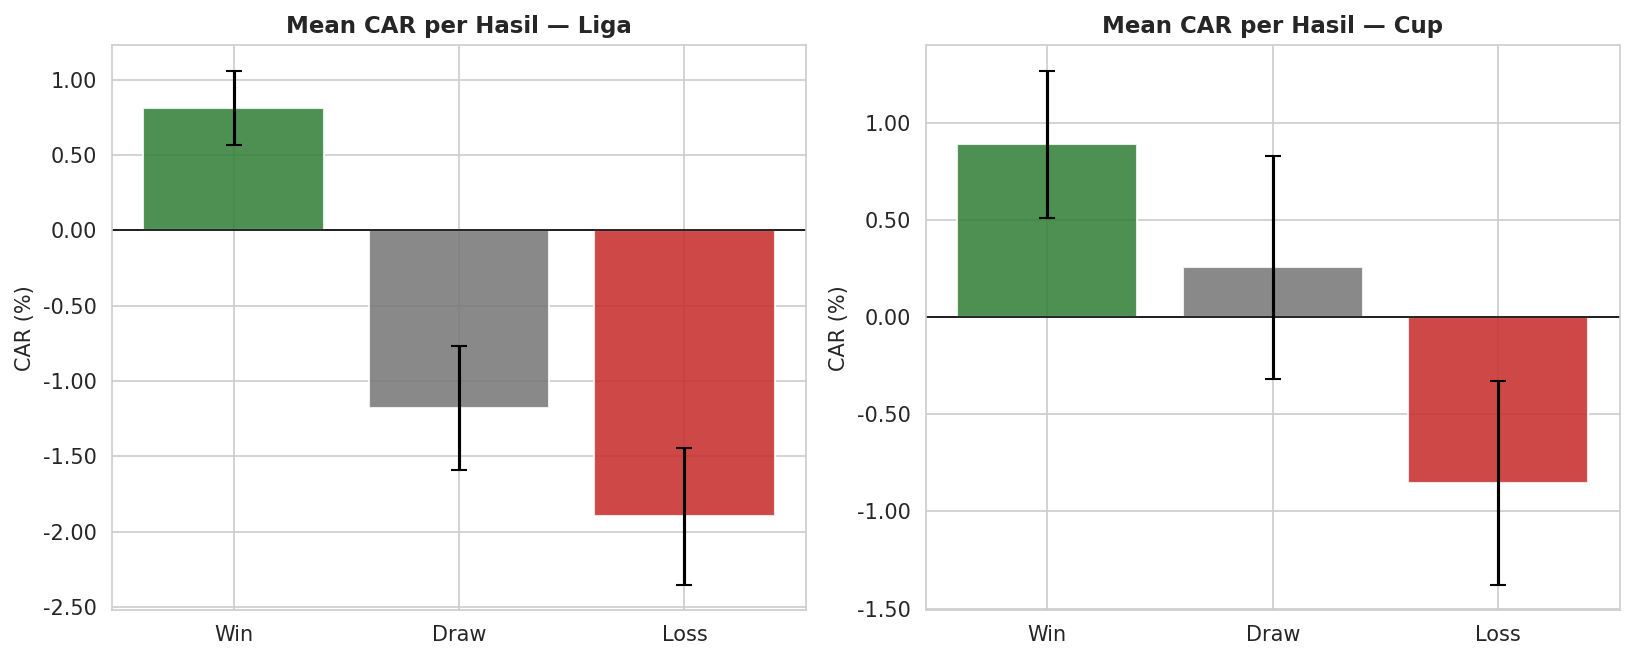

✅ Grafik1_CAR_per_Hasil.png tersimpan


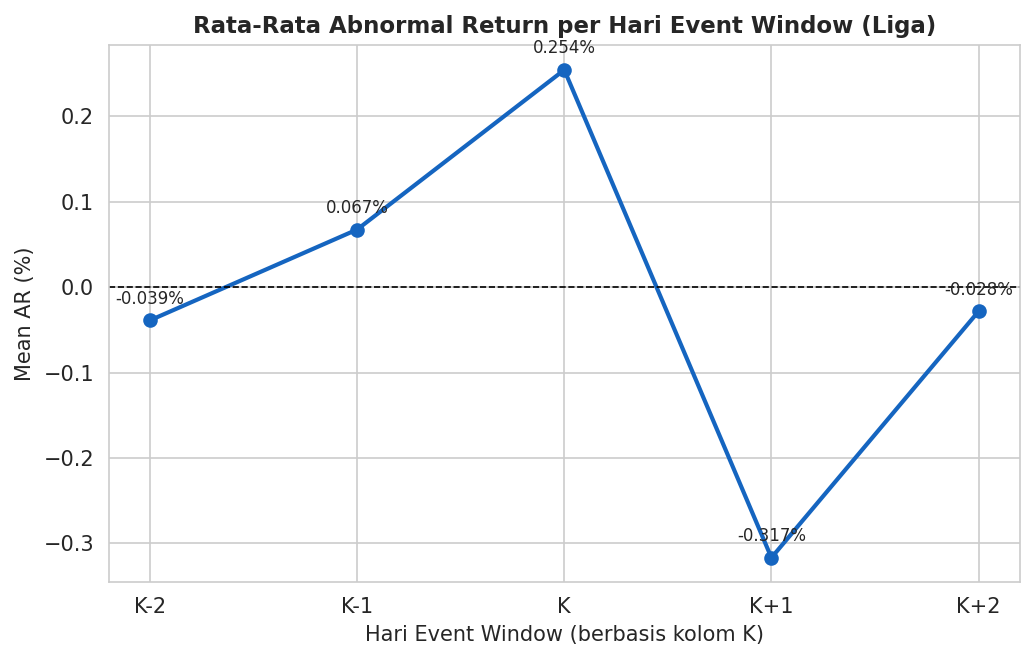

✅ Grafik2_AR_Event_Window.png tersimpan


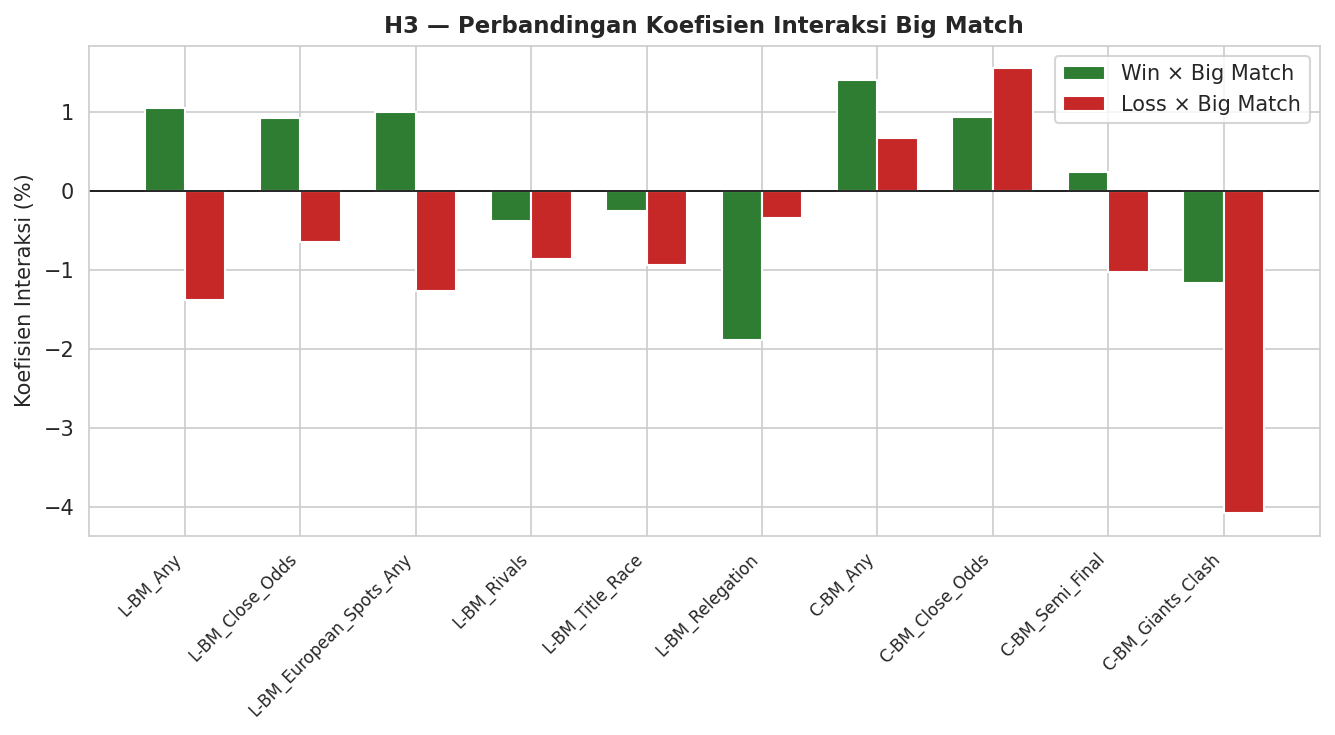

✅ Grafik3_H3_BigMatch_Interaksi.png tersimpan


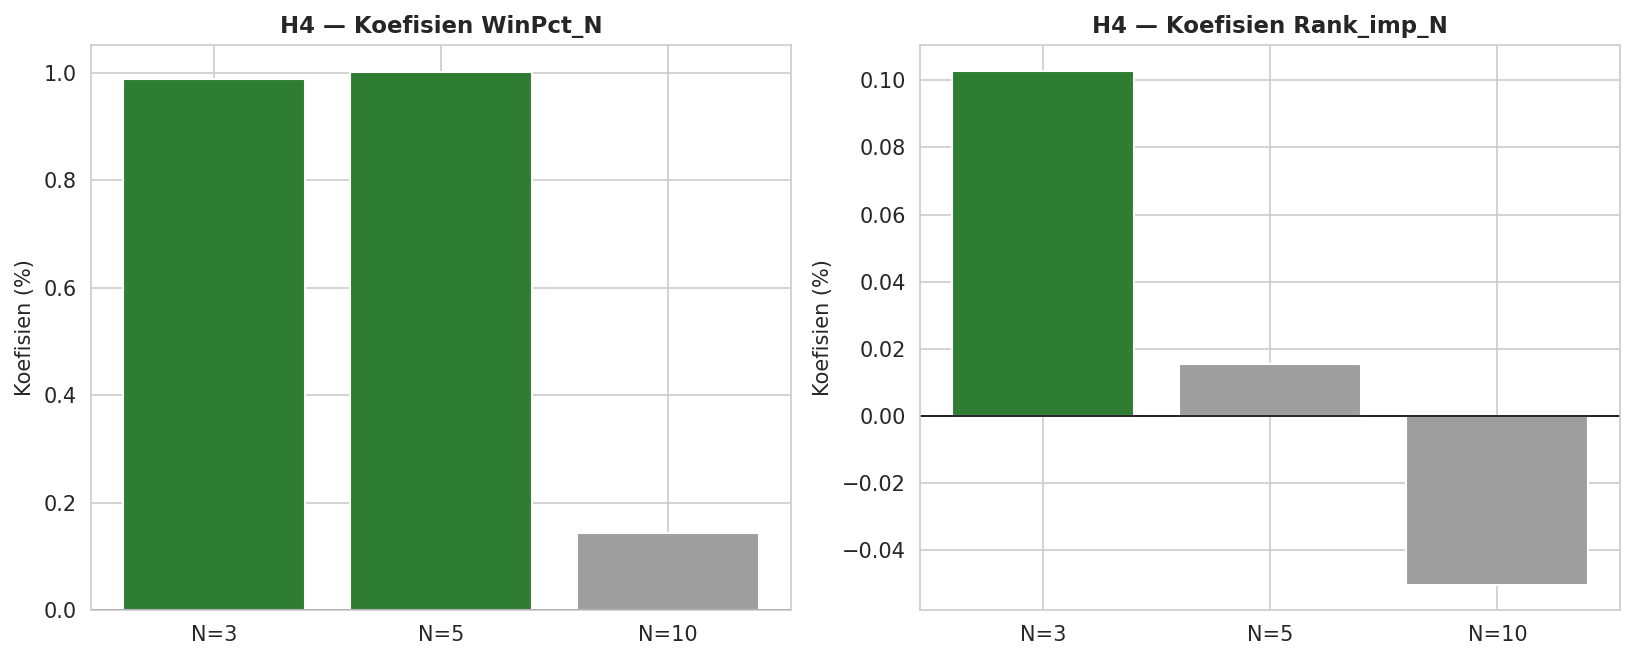

✅ Grafik4_H4_Rolling_Form.png tersimpan


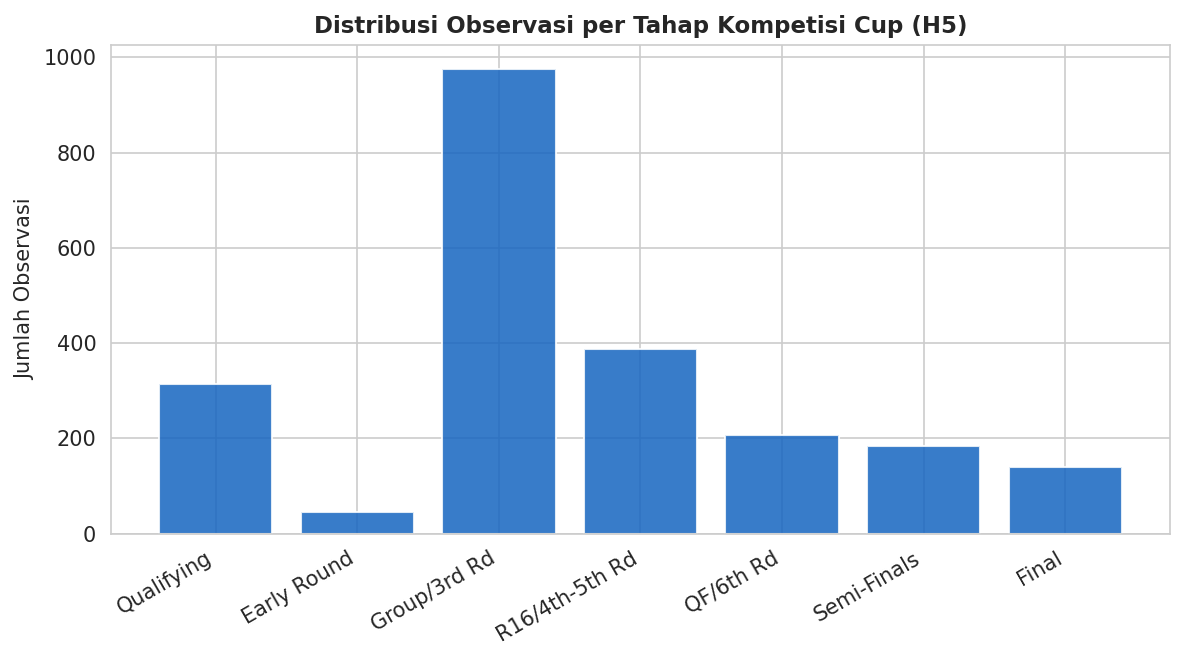

✅ Grafik5_Distribusi_Stage_Cup.png tersimpan

✅ Semua grafik tersimpan di /content/ — bisa langsung di-screenshot atau didownload
   (klik ikon folder di panel kiri Colab untuk melihat file .png)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

print("\n" + "="*65)
print("VISUALISASI GRAFIK")
print("="*65)

# ── Grafik 1: Mean CAR per Hasil Pertandingan (Liga vs Cup) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, df, title in [(axes[0], df_liga, "Liga"), (axes[1], df_cup, "Cup")]:
    means, errs, labels_, colors = [], [], [], []
    for r, name, c in [('W','Win','#2E7D32'), ('D','Draw','#757575'), ('L','Loss','#C62828')]:
        sub = df[df['Results'] == r]['CAR'].dropna()
        if len(sub) == 0: continue
        means.append(sub.mean()*100)
        errs.append(sub.sem()*100*1.96)
        labels_.append(name); colors.append(c)
    bars = ax.bar(labels_, means, yerr=errs, capsize=4, color=colors, alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f"Mean CAR per Hasil — {title}", fontsize=11, fontweight='bold')
    ax.set_ylabel("CAR (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.savefig("Grafik1_CAR_per_Hasil.png", bbox_inches='tight')
plt.show()
print("✅ Grafik1_CAR_per_Hasil.png tersimpan")

# ── Grafik 2: Rata-rata AR per Hari Event Window (Liga) ─────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))
days = ['K-2','K-1','K','K+1','K+2']
means_ar = [df_liga[c].mean()*100 for c in ['AR_m2','AR_m1','AR_0','AR_p1','AR_p2']]
ax.plot(days, means_ar, marker='o', linewidth=2, color='#1565C0')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title("Rata-Rata Abnormal Return per Hari Event Window (Liga)", fontsize=11, fontweight='bold')
ax.set_ylabel("Mean AR (%)")
ax.set_xlabel("Hari Event Window (berbasis kolom K)")
for x, y in zip(days, means_ar):
    ax.annotate(f"{y:.3f}%", (x, y), textcoords="offset points", xytext=(0,8), ha='center', fontsize=8)
plt.tight_layout()
plt.savefig("Grafik2_AR_Event_Window.png", bbox_inches='tight')
plt.show()
print("✅ Grafik2_AR_Event_Window.png tersimpan")

# ── Grafik 3: Perbandingan Koefisien Interaksi H3 (Big Match) ───────────────
h3_plot_rows = []
for name, m in h3_models.items():
    win_key = [k for k in m.params.index if 'Win:' in k or ':Win' in k]
    los_key = [k for k in m.params.index if 'Loss:' in k or ':Loss' in k]
    if win_key and los_key:
        h3_plot_rows.append({
            'Model': name.replace('Liga_','L-').replace('Cup_','C-'),
            'Win×BM': m.params[win_key[0]],
            'Loss×BM': m.params[los_key[0]],
            'p_Win': m.pvalues[win_key[0]],
            'p_Loss': m.pvalues[los_key[0]],
        })
df_h3plot = pd.DataFrame(h3_plot_rows)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(df_h3plot))
width = 0.35
bars1 = ax.bar(x - width/2, df_h3plot['Win×BM']*100, width, label='Win × Big Match', color='#2E7D32')
bars2 = ax.bar(x + width/2, df_h3plot['Loss×BM']*100, width, label='Loss × Big Match', color='#C62828')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_h3plot['Model'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Koefisien Interaksi (%)")
ax.set_title("H3 — Perbandingan Koefisien Interaksi Big Match", fontsize=11, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("Grafik3_H3_BigMatch_Interaksi.png", bbox_inches='tight')
plt.show()
print("✅ Grafik3_H3_BigMatch_Interaksi.png tersimpan")

# ── Grafik 4: H4 Rolling Form — Koefisien per N ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, prefix, title in [(axes[0], 'WinPct', 'WinPct_N'), (axes[1], 'Rank_imp', 'Rank_imp_N')]:
    ns, bs, ps = [], [], []
    for N in [3, 5, 10]:
        key = f'{prefix}_{N}'
        m = h4_models.get(key)
        if m is None or key not in m.params: continue
        ns.append(f"N={N}"); bs.append(m.params[key]*100); ps.append(m.pvalues[key])
    colors = ['#2E7D32' if p < 0.05 else '#F9A825' if p < 0.10 else '#9E9E9E' for p in ps]
    ax.bar(ns, bs, color=colors)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f"H4 — Koefisien {title}", fontsize=11, fontweight='bold')
    ax.set_ylabel("Koefisien (%)")
plt.tight_layout()
plt.savefig("Grafik4_H4_Rolling_Form.png", bbox_inches='tight')
plt.show()
print("✅ Grafik4_H4_Rolling_Form.png tersimpan")

# ── Grafik 5: Distribusi Observasi per Stage (Cup, H5) ──────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))
stage_labels = {1:'Qualifying', 2:'Early Round', 3:'Group/3rd Rd', 4:'R16/4th-5th Rd',
                5:'QF/6th Rd', 6:'Semi-Finals', 7:'Final'}
counts = df_cup['Stage_Num'].value_counts().sort_index()
ax.bar([stage_labels.get(i, i) for i in counts.index], counts.values, color='#1565C0', alpha=0.85)
ax.set_title("Distribusi Observasi per Tahap Kompetisi Cup (H5)", fontsize=11, fontweight='bold')
ax.set_ylabel("Jumlah Observasi")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("Grafik5_Distribusi_Stage_Cup.png", bbox_inches='tight')
plt.show()
print("✅ Grafik5_Distribusi_Stage_Cup.png tersimpan")

print("\n✅ Semua grafik tersimpan di /content/ — bisa langsung di-screenshot atau didownload")
print("   (klik ikon folder di panel kiri Colab untuk melihat file .png)")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
print("\n" + "="*65)
print("EXPORT HASIL KE EXCEL")
print("="*65)

def model_to_row(name, model):
    """Ekstrak info utama dari model untuk tabel ringkasan."""
    row = {
        'Model': name,
        'N': int(model.nobs),
        'R2': round(model.rsquared, 4),
        'Adj_R2': round(model.rsquared_adj, 4),
        'F_stat': round(float(model.fvalue), 4),
        'Prob_F': round(float(model.f_pvalue), 6),
    }
    for var in ['Win', 'Loss', 'Surprise', 'WinPct_5', 'Rank_imp_5',
                'Stage_Num', 'Eliminated', 'Advanced']:
        if var in model.params:
            row[f'b_{var}']    = round(model.params[var], 5)
            row[f'p_{var}']    = round(model.pvalues[var], 4)
            row[f'sig_{var}']  = ('***' if model.pvalues[var] < 0.01 else
                                  '**'  if model.pvalues[var] < 0.05 else
                                  '*'   if model.pvalues[var] < 0.10 else '—')
    return row

# Kumpulkan semua model utama
all_models = {
    'H1 Liga Main':        h1_liga,
    'H1 Liga CARpre':      h1_liga_pre,
    'H1 Liga CARpost':     h1_liga_post,
    'H1 Liga Top vs Mid':  h1_tier,
    'H1 Cup Main':         h1_cup,
    'H1 Cup CARpre':       h1_cup_pre,
    'H1 Cup CARpost':      h1_cup_post,
    'H2A Liga Surprise':   h2a_liga,
    'H2B Liga WinxSurp':   h2b_liga,
    'H2A Cup Surprise':    h2a_cup,
    'H2 Pooled':           h2_pool,
    'H4A WinPct_3':        h4_models.get('WinPct_3'),
    'H4A WinPct_5':        h4_models.get('WinPct_5'),
    'H4A WinPct_10':       h4_models.get('WinPct_10'),
    'H4B Rank_imp_3':      h4_models.get('Rank_imp_3'),
    'H4B Rank_imp_5':      h4_models.get('Rank_imp_5'),
    'H4B Rank_imp_10':     h4_models.get('Rank_imp_10'),
    'H5A Stage Mod':       h5a,
    'H5B Elimination':     h5b,
    'H5C Qualification':   h5c,
    'R1 Market-Adj':       h1_madj,
    'R2 WinPct NOverlap':  h4_robust,
}

# Tambahkan H3
for name, m in h3_models.items():
    all_models[f'H3 {name}'] = m

# Build summary DataFrame
rows = []
for name, m in all_models.items():
    if m is not None:
        rows.append(model_to_row(name, m))

df_summary = pd.DataFrame(rows)

# Export ke Excel dengan multiple sheets
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment

OUTPUT_FILE = "hasil_analisis_skripsi.xlsx"

with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:
    # Sheet 1: Ringkasan semua model
    df_summary.to_excel(writer, sheet_name='Ringkasan_Model', index=False)

    # Sheet 2: Statistik deskriptif
    desc_rows = []
    for dataset, df, label in [
        ('Liga', df_liga, 'Liga'), ('Cup', df_cup, 'Cup')
    ]:
        for r, name in [('W','Win'), ('D','Draw'), ('L','Loss')]:
            sub = df[df['Results'] == r]['CAR'].dropna()
            if len(sub) == 0: continue
            t, p = ttest_1samp(sub, 0)
            desc_rows.append({
                'Dataset': label, 'Hasil': name, 'N': len(sub),
                'Mean_CAR': round(sub.mean(), 5), 'Std_CAR': round(sub.std(), 5),
                'Min_CAR': round(sub.min(), 5), 'Max_CAR': round(sub.max(), 5),
                't_stat': round(t, 4), 'p_value': round(p, 4),
                'Signifikan': '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else '—'
            })
    pd.DataFrame(desc_rows).to_excel(writer, sheet_name='Deskriptif', index=False)

    # Sheet 3: H3 Koefisien Interaksi Detail
    h3_rows = []
    for name, m in h3_models.items():
        win_key = [k for k in m.params.index if 'Win:' in k or ':Win' in k]
        los_key = [k for k in m.params.index if 'Loss:' in k or ':Loss' in k]
        if win_key and los_key:
            h3_rows.append({
                'Model': name,
                'N': int(m.nobs),
                'b_Win': round(m.params['Win'], 5),
                'p_Win': round(m.pvalues['Win'], 4),
                'b_Loss': round(m.params['Loss'], 5),
                'p_Loss': round(m.pvalues['Loss'], 4),
                'b_Win_BM': round(m.params[win_key[0]], 5),
                'p_Win_BM': round(m.pvalues[win_key[0]], 4),
                'sig_Win_BM': ('***' if m.pvalues[win_key[0]]<0.01 else
                               '**' if m.pvalues[win_key[0]]<0.05 else
                               '*' if m.pvalues[win_key[0]]<0.10 else '—'),
                'b_Loss_BM': round(m.params[los_key[0]], 5),
                'p_Loss_BM': round(m.pvalues[los_key[0]], 4),
                'sig_Loss_BM': ('***' if m.pvalues[los_key[0]]<0.01 else
                                '**' if m.pvalues[los_key[0]]<0.05 else
                                '*' if m.pvalues[los_key[0]]<0.10 else '—'),
                'R2': round(m.rsquared, 4),
            })
    pd.DataFrame(h3_rows).to_excel(writer, sheet_name='H3_BigMatch_Detail', index=False)

    # Sheet 4: Wald Test Loss Aversion
    wald_rows = []
    for label, m, ds in [('H1 Liga', h1_liga, 'Liga'), ('H1 Cup', h1_cup, 'Cup')]:
        try:
            res = m.f_test("Win + Loss = 0")
            wald_rows.append({
                'Model': label, 'Dataset': ds,
                'b_Win': round(m.params['Win'], 5),
                'b_Loss': round(m.params['Loss'], 5),
                'Ratio_Loss_Win': round(abs(m.params['Loss']/m.params['Win']), 3),
                'F_stat': round(float(res.fvalue), 4),
                'p_value': round(float(res.pvalue), 4),
                'Kesimpulan': ('Asimetri signifikan (loss aversion)'
                               if float(res.pvalue) < 0.05 else 'Tidak ada asimetri')
            })
        except: pass
    pd.DataFrame(wald_rows).to_excel(writer, sheet_name='Wald_LossAversion', index=False)

    # Sheet 5: H4 Summary
    h4_rows = []
    for label, m in h4_models.items():
        if m is None: continue
        var = label
        if var in m.params:
            h4_rows.append({
                'Model': label, 'Var_Utama': var, 'N': int(m.nobs),
                'b_main': round(m.params[var], 5),
                'p_main': round(m.pvalues[var], 4),
                'sig': ('***' if m.pvalues[var]<0.01 else
                        '**' if m.pvalues[var]<0.05 else
                        '*' if m.pvalues[var]<0.10 else '—'),
                'b_Win': round(m.params.get('Win', np.nan), 5),
                'b_Loss': round(m.params.get('Loss', np.nan), 5),
                'R2': round(m.rsquared, 4),
            })
    pd.DataFrame(h4_rows).to_excel(writer, sheet_name='H4_Rolling_Summary', index=False)

print(f"\n✅ File berhasil disimpan: {OUTPUT_FILE}")
print("📥 Download: klik ikon folder di panel kiri Colab → temukan file tersebut")

# ── Download otomatis ────────────────────────────────────────────────────────
from google.colab import files
files.download(OUTPUT_FILE)


EXPORT HASIL KE EXCEL

✅ File berhasil disimpan: hasil_analisis_skripsi.xlsx
📥 Download: klik ikon folder di panel kiri Colab → temukan file tersebut


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("\n" + "="*65)
print("RINGKASAN AKHIR ANALISIS")
print("="*65)
print(f"\n{'Model':<35} {'N':>7} {'R²':>7} {'F-stat':>9} {'Prob(F)':>10} {'Key β':>12} {'p':>8}")
print("─"*94)

key_info = [
    ("H1 Liga — Win", h1_liga, 'Win'),
    ("H1 Liga — Loss", h1_liga, 'Loss'),
    ("H1 Cup — Win", h1_cup, 'Win'),
    ("H1 Cup — Loss", h1_cup, 'Loss'),
    ("H2A Liga — Surprise", h2a_liga, 'Surprise'),
    ("H2A Cup — Surprise", h2a_cup, 'Surprise'),
    ("H4A WinPct_5 (Liga)", h4_models.get('WinPct_5'), 'WinPct_5'),
    ("H4B Rank_imp_5 (Liga)", h4_models.get('Rank_imp_5'), 'Rank_imp_5'),
    ("H5A Win×Stage (Cup)", h5a, 'Win:Stage_Num'),
    ("H5A Loss×Stage (Cup)", h5a, 'Loss:Stage_Num'),
    ("H5B Eliminated (Cup)", h5b, 'Eliminated'),
]

for label, m, var in key_info:
    if m is None: continue
    # Find var (handle interaction notation)
    found = [k for k in m.params.index if k == var or
             (var in k and ':' in var)]
    if not found: continue
    vk = found[0]
    b = m.params[vk]; p = m.pvalues[vk]
    star = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else '—'
    print(f"  {label:<33} {int(m.nobs):>7} {m.rsquared:>7.4f} {m.fvalue:>9.3f} {m.f_pvalue:>10.4g} {b:>12.5f} {p:>7.4f} {star}")

print("\n" + "="*65)
print("ANALISIS SELESAI ✅")
print("="*65)
print("""
Signifikansi: *** p<0.01 | ** p<0.05 | * p<0.10 | — tidak signifikan

Interpretasi:
  H1: β_Win > 0 dan β_Loss < 0 → kemenangan positif, kekalahan negatif
  H2: β_Surprise > 0 → unexpected result → reaksi lebih besar
  H3: β_Win×BM > 0 dan β_Loss×BM < 0 → big match memperkuat efek
  H4: β_WinPct/Rank_imp > 0 → form/momentum berpengaruh positif
  H5: β_Win×Stage > 0 → semakin lanjut tahap, reaksi semakin kuat
""")


RINGKASAN AKHIR ANALISIS

Model                                     N      R²    F-stat    Prob(F)        Key β        p
──────────────────────────────────────────────────────────────────────────────────────────────
  H1 Liga — Win                        5093  0.0321    35.453  1.748e-07      0.01996  0.0000 ***
  H1 Liga — Loss                       5093  0.0321    35.453  1.748e-07     -0.00762  0.0146 **
  H1 Cup — Win                         2258  0.0262     8.884  0.0003154      0.00696  0.2305 —
  H1 Cup — Loss                        2258  0.0262     8.884  0.0003154     -0.01192  0.0652 *
  H2A Liga — Surprise                  4989  0.0333    38.955  1.019e-07      0.00998  0.0782 *
  H2A Cup — Surprise                   2035  0.0293     7.208  0.0008728      0.01187  0.0070 ***
  H4A WinPct_5 (Liga)                  5028  0.0333     7.293  0.0008253      0.01001  0.0250 **
  H4B Rank_imp_5 (Liga)                4378  0.0300    10.037  0.0001708      0.00015  0.7115 —
  H5A Win